# Classification par Intervalles d'Âge + Visualisation des Filtres CNN

## Objectifs

### 1. Classification par intervalles d'âge

Au lieu de prédire un âge exact (régression), on prédit des **tranches d'âge** (classification).

**Avantages:**

- Plus robuste aux variations
- Métriques plus interprétables (Precision, Recall, F1)
- Confiance par classe

### 2. Visualisation des filtres CNN

Comprendre ce que le modèle "voit" à chaque couche:

- **Couches basses**: Edges, contours
- **Couches intermédiaires**: Textures, patterns
- **Couches hautes**: Formes complexes, parties du visage

### 3. Grad-CAM

Visualiser sur quoi le modèle se focalise pour chaque prédiction (Genre, Âge, Ethnicité).


---
# PARTIE 1 : Classification par Intervalles d'Âge
---


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from scipy import stats
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.regularizers import l2

# GPU
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {gpus}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6)})

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1.1 Définition des Intervalles d'Âge

On peut choisir différents intervalles selon l'application:


In [2]:
# Configuration
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data" / "UTKFace"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20

# ════════════════════════════════════════════════════════════════
# DÉFINITION DES INTERVALLES D'ÂGE
# ════════════════════════════════════════════════════════════════

# Option 1: Intervalles égaux (simple)
AGE_BINS_EQUAL = [0, 10, 20, 30, 40, 50, 60, 70, 120]
AGE_LABELS_EQUAL = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71+"]

# Option 2: Intervalles basés sur les stades de vie (plus naturel)
AGE_BINS_LIFE = [0, 3, 12, 20, 35, 50, 65, 120]
AGE_LABELS_LIFE = [
    "Bébé (0-2)",
    "Enfant (3-11)",
    "Ado (12-19)",
    "Jeune adulte (20-34)",
    "Adulte (35-49)",
    "Senior (50-64)",
    "Âgé (65+)",
]

# Option 3: Intervalles optimisés pour le dataset (basé sur la distribution)
AGE_BINS_OPTIMIZED = [0, 5, 15, 25, 35, 45, 60, 120]
AGE_LABELS_OPTIMIZED = ["0-4", "5-14", "15-24", "25-34", "35-44", "45-59", "60+"]

# Choix pour l'expérience
AGE_BINS = AGE_BINS_LIFE
AGE_LABELS = AGE_LABELS_LIFE
NUM_AGE_CLASSES = len(AGE_LABELS)

print("Intervalles d'âge choisis:")
for i, label in enumerate(AGE_LABELS):
    print(f"  Classe {i}: {label}")


def age_to_class(age):
    """Convertit un âge en classe (intervalle)."""
    for i, (low, high) in enumerate(zip(AGE_BINS[:-1], AGE_BINS[1:])):
        if low <= age < high:
            return i
    return len(AGE_BINS) - 2  # Dernière classe

Intervalles d'âge choisis:
  Classe 0: Bébé (0-2)
  Classe 1: Enfant (3-11)
  Classe 2: Ado (12-19)
  Classe 3: Jeune adulte (20-34)
  Classe 4: Adulte (35-49)
  Classe 5: Senior (50-64)
  Classe 6: Âgé (65+)


## 1.2 Chargement et Préparation des Données


In [3]:
def parse_utkface(filepath):
    filename = Path(filepath).stem
    parts = filename.split("_")
    if len(parts) >= 3:
        try:
            age = int(parts[0])
            gender = int(parts[1])
            ethnicity = int(parts[2])
            if 0 <= age <= 116 and gender in [0, 1] and 0 <= ethnicity <= 4:
                return {
                    "filepath": str(filepath),
                    "age": age,
                    "age_class": age_to_class(age),
                    "gender": gender,
                    "ethnicity": ethnicity,
                }
        except:
            pass
    return None


# Charger
image_paths = list(DATA_DIR.glob("*.jpg")) + list(DATA_DIR.glob("*.JPG"))
records = [parse_utkface(p) for p in tqdm(image_paths, desc="Parsing")]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)

# Nettoyage
z_scores = np.abs(stats.zscore(df["age"]))
df_clean = df[z_scores <= 3].copy()

print(f"Images: {len(df_clean)}")
print(f"\nDistribution par classe d'âge:")
for i, label in enumerate(AGE_LABELS):
    count = (df_clean["age_class"] == i).sum()
    pct = count / len(df_clean) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:20s}: {count:5d} ({pct:5.1f}%) {bar}")

Parsing: 100%|██████████| 23708/23708 [00:00<00:00, 88064.27it/s]


Images: 23633

Distribution par classe d'âge:
  Bébé (0-2)          :  1605 (  6.8%) ███
  Enfant (3-11)       :  1678 (  7.1%) ███
  Ado (12-19)         :  1310 (  5.5%) ██
  Jeune adulte (20-34):  9634 ( 40.8%) ████████████████████
  Adulte (35-49)      :  4491 ( 19.0%) █████████
  Senior (50-64)      :  3029 ( 12.8%) ██████
  Âgé (65+)           :  1886 (  8.0%) ███


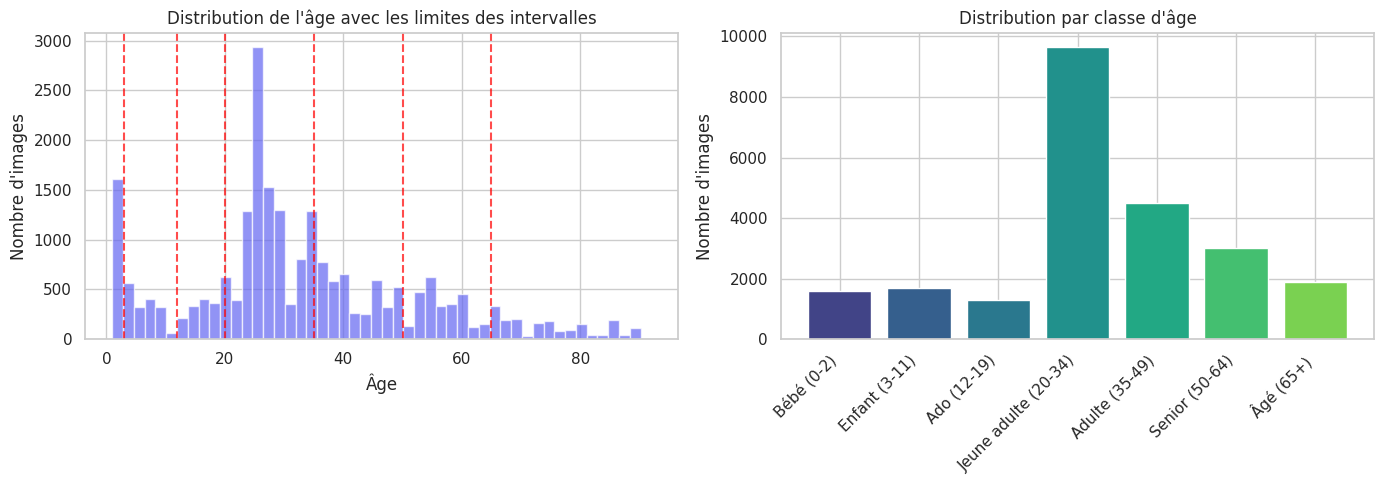

In [4]:
# Visualiser la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution continue de l'âge
axes[0].hist(df_clean["age"], bins=50, color="#6366F1", edgecolor="white", alpha=0.7)
for bin_edge in AGE_BINS[1:-1]:
    axes[0].axvline(x=bin_edge, color="red", linestyle="--", alpha=0.7)
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution de l'âge avec les limites des intervalles")

# Distribution par classe
class_counts = df_clean["age_class"].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, NUM_AGE_CLASSES))
bars = axes[1].bar(
    range(NUM_AGE_CLASSES),
    [class_counts.get(i, 0) for i in range(NUM_AGE_CLASSES)],
    color=colors,
    edgecolor="white",
)
axes[1].set_xticks(range(NUM_AGE_CLASSES))
axes[1].set_xticklabels(AGE_LABELS, rotation=45, ha="right")
axes[1].set_ylabel("Nombre d'images")
axes[1].set_title("Distribution par classe d'âge")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "age_intervals_distribution.png", dpi=150)
plt.show()

## 1.3 Modèle avec Classification d'Âge


In [5]:
# Préparation des données
X = df_clean["filepath"].values
y_age_class = df_clean["age_class"].values.astype(np.int32)
y_gender = df_clean["gender"].values.astype(np.int32)
y_ethnicity = df_clean["ethnicity"].values.astype(np.int32)

# Split
(
    X_train,
    X_test,
    y_age_train,
    y_age_test,
    y_gender_train,
    y_gender_test,
    y_eth_train,
    y_eth_test,
) = train_test_split(
    X,
    y_age_class,
    y_gender,
    y_ethnicity,
    test_size=0.15,
    random_state=SEED,
    stratify=y_age_class,
)

(
    X_train,
    X_val,
    y_age_train,
    y_age_val,
    y_gender_train,
    y_gender_val,
    y_eth_train,
    y_eth_val,
) = train_test_split(
    X_train,
    y_age_train,
    y_gender_train,
    y_eth_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_age_train,
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 17074, Val: 3014, Test: 3545


In [6]:
# Data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ]
)


def load_image(filepath, age_class, gender, ethnicity):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, {
        "age_output": age_class,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def create_dataset(X, y_age, y_gender, y_eth, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y_age, y_gender, y_eth))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train, y_age_train, y_gender_train, y_eth_train, training=True
)
val_ds = create_dataset(X_val, y_age_val, y_gender_val, y_eth_val)
test_ds = create_dataset(X_test, y_age_test, y_gender_test, y_eth_test)

print("Datasets créés")

I0000 00:00:1769158265.387030   52688 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3771 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets créés


In [7]:
def build_classification_model():
    """Modèle avec âge en CLASSIFICATION (intervalles) au lieu de régression."""

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    # Backbone
    backbone = MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        include_preprocessing=True,
    )
    backbone.trainable = False

    features = backbone.output
    pooled = layers.GlobalAveragePooling2D()(features)

    # Shared
    shared = layers.Dense(256, kernel_regularizer=l2(1e-4))(pooled)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Activation("relu")(shared)
    shared = layers.Dropout(0.4)(shared)

    # ═══════════════════════════════════════════════════════════
    # ÂGE: CLASSIFICATION (Softmax sur les intervalles)
    # ═══════════════════════════════════════════════════════════
    age_branch = layers.Dense(128, activation="relu")(shared)
    age_branch = layers.Dropout(0.3)(age_branch)
    age_output = layers.Dense(NUM_AGE_CLASSES, activation="softmax", name="age_output")(
        age_branch
    )

    # Genre: Classification binaire
    gender_branch = layers.Dense(64, activation="relu")(shared)
    gender_branch = layers.Dropout(0.3)(gender_branch)
    gender_output = layers.Dense(1, activation="sigmoid", name="gender_output")(
        gender_branch
    )

    # Ethnicité: Classification multi-classe
    eth_branch = layers.Dense(64, activation="relu")(shared)
    eth_branch = layers.Dropout(0.3)(eth_branch)
    ethnicity_output = layers.Dense(5, activation="softmax", name="ethnicity_output")(
        eth_branch
    )

    model = Model(inputs=inputs, outputs=[age_output, gender_output, ethnicity_output])
    return model, backbone


model, backbone = build_classification_model()

print(f"Modèle créé")
print(f"  - Âge: {NUM_AGE_CLASSES} classes (softmax)")
print(f"  - Genre: 1 sortie (sigmoid)")
print(f"  - Ethnicité: 5 classes (softmax)")

Modèle créé
  - Âge: 7 classes (softmax)
  - Genre: 1 sortie (sigmoid)
  - Ethnicité: 5 classes (softmax)


In [8]:
# Compilation
model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss={
        "age_output": keras.losses.SparseCategoricalCrossentropy(),  # Classification!
        "gender_output": keras.losses.BinaryCrossentropy(),
        "ethnicity_output": keras.losses.SparseCategoricalCrossentropy(),
    },
    metrics={
        "age_output": ["accuracy"],
        "gender_output": ["accuracy"],
        "ethnicity_output": ["accuracy"],
    },
)

print("Modèle compilé avec SparseCategoricalCrossentropy pour l'âge")

Modèle compilé avec SparseCategoricalCrossentropy pour l'âge


In [9]:
# Entraînement
print("=" * 60)
print("ENTRAÎNEMENT - Modèle avec Classification d'Âge")
print("=" * 60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            str(ARTIFACTS_DIR / "age_classification_model.keras"),
            monitor="val_loss",
            save_best_only=True,
        ),
    ],
    verbose=1,
)

ENTRAÎNEMENT - Modèle avec Classification d'Âge
Epoch 1/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - age_output_accuracy: 0.4842 - age_output_loss: 1.3479 - ethnicity_output_accuracy: 0.5091 - ethnicity_output_loss: 1.2657 - gender_output_accuracy: 0.7458 - gender_output_loss: 0.5112 - loss: 3.1631 - val_age_output_accuracy: 0.5591 - val_age_output_loss: 1.1267 - val_ethnicity_output_accuracy: 0.5820 - val_ethnicity_output_loss: 1.0774 - val_gender_output_accuracy: 0.8212 - val_gender_output_loss: 0.3837 - val_loss: 2.6230
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - age_output_accuracy: 0.5303 - age_output_loss: 1.1924 - ethnicity_output_accuracy: 0.5828 - ethnicity_output_loss: 1.1038 - gender_output_accuracy: 0.7940 - gender_output_loss: 0.4374 - loss: 2.7750 - val_age_output_accuracy: 0.5438 - val_age_output_loss: 1.1476 - val_ethnicity_output_accuracy: 0.5962 - val_ethnicity_output_loss: 1.0605 - val_gender_output_accuracy: 0.8271 - val_gender_output_loss: 0.3684 - v

## 1.4 Évaluation avec Métriques de Classification


In [10]:
# Prédictions
predictions = model.predict(test_ds, verbose=1)

y_pred_age = np.argmax(predictions[0], axis=1)
y_pred_gender = (predictions[1].flatten() > 0.5).astype(int)
y_pred_ethnicity = np.argmax(predictions[2], axis=1)

# Métriques
print("\n" + "=" * 70)
print("          RÉSULTATS - CLASSIFICATION PAR INTERVALLES D'ÂGE")
print("=" * 70)

print("\n📊 ÂGE (Classification):")
print(f"   Accuracy: {accuracy_score(y_age_test, y_pred_age)*100:.2f}%")
print(f"   F1-Score (macro): {f1_score(y_age_test, y_pred_age, average='macro'):.4f}")
print(
    f"   F1-Score (weighted): {f1_score(y_age_test, y_pred_age, average='weighted'):.4f}"
)

print("\n👫 GENRE:")
print(f"   Accuracy: {accuracy_score(y_gender_test, y_pred_gender)*100:.2f}%")

print("\n🌍 ETHNICITÉ:")
print(f"   Accuracy: {accuracy_score(y_eth_test, y_pred_ethnicity)*100:.2f}%")

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

          RÉSULTATS - CLASSIFICATION PAR INTERVALLES D'ÂGE

📊 ÂGE (Classification):
   Accuracy: 57.66%
   F1-Score (macro): 0.5148
   F1-Score (weighted): 0.5563

👫 GENRE:
   Accuracy: 84.85%

🌍 ETHNICITÉ:
   Accuracy: 64.63%


In [11]:
# Rapport détaillé pour l'âge
print("\n" + "=" * 70)
print("RAPPORT DÉTAILLÉ - CLASSIFICATION ÂGE")
print("=" * 70)
print(
    classification_report(
        y_age_test, y_pred_age, target_names=AGE_LABELS, zero_division=0
    )
)


RAPPORT DÉTAILLÉ - CLASSIFICATION ÂGE
                      precision    recall  f1-score   support

          Bébé (0-2)       0.87      0.74      0.80       241
       Enfant (3-11)       0.54      0.44      0.49       252
         Ado (12-19)       0.45      0.24      0.31       196
Jeune adulte (20-34)       0.65      0.82      0.72      1445
      Adulte (35-49)       0.39      0.27      0.32       674
      Senior (50-64)       0.39      0.35      0.37       454
           Âgé (65+)       0.54      0.64      0.59       283

            accuracy                           0.58      3545
           macro avg       0.55      0.50      0.51      3545
        weighted avg       0.56      0.58      0.56      3545



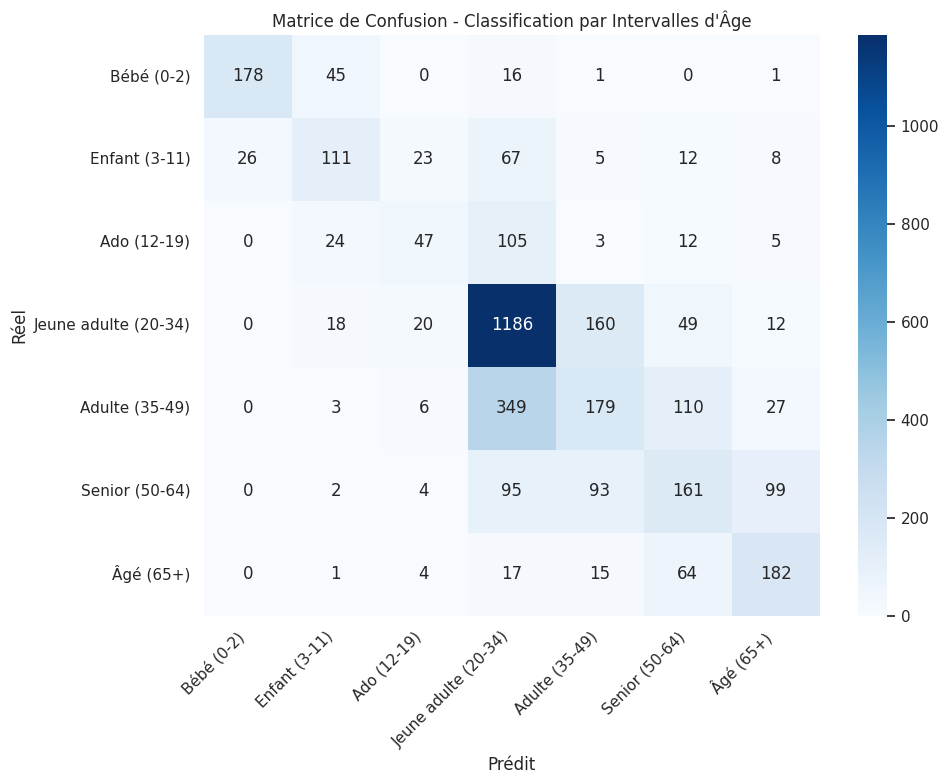


💡 Observation: Les erreurs sont souvent entre classes adjacentes
   (ex: confondre 'Jeune adulte' avec 'Adulte' est moins grave que 'Bébé' avec 'Âgé')


In [12]:
# Matrice de confusion pour l'âge
cm = confusion_matrix(y_age_test, y_pred_age)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=AGE_LABELS,
    yticklabels=AGE_LABELS,
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de Confusion - Classification par Intervalles d'Âge")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "age_classification_confusion_matrix.png", dpi=150)
plt.show()

print("\n💡 Observation: Les erreurs sont souvent entre classes adjacentes")
print(
    "   (ex: confondre 'Jeune adulte' avec 'Adulte' est moins grave que 'Bébé' avec 'Âgé')"
)

---
# PARTIE 2 : Visualisation des Filtres CNN
---

## Qu'est-ce que les filtres capturent ?

```
Couche 1 (premiers filtres):    Edges, contours basiques
Couche 2-3:                     Textures, patterns
Couches intermédiaires:         Formes, parties d'objets
Couches profondes:              Concepts abstraits, visages entiers
```


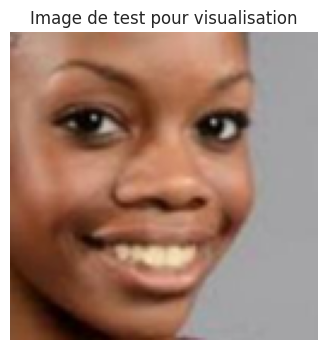

In [13]:
# Charger une image de test
sample_path = X_test[0]
sample_img = Image.open(sample_path).resize((IMG_SIZE, IMG_SIZE))
sample_array = np.array(sample_img).astype(np.float32)
sample_batch = np.expand_dims(sample_array, axis=0)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title("Image de test pour visualisation")
plt.axis("off")
plt.show()

In [14]:
# Lister les couches du backbone
print("Couches du backbone MobileNetV3:")
print("-" * 50)
for i, layer in enumerate(backbone.layers[:20]):  # Premiers 20
    output_shape = layer.output.shape if hasattr(layer, "output") else "N/A"
    print(f"{i:3d}: {layer.name:40s} -> {output_shape}")
print("...")
print(f"\nTotal: {len(backbone.layers)} couches")

Couches du backbone MobileNetV3:
--------------------------------------------------
  0: input_layer                              -> (None, 128, 128, 3)
  1: sequential                               -> (None, 128, 128, 3)
  2: rescaling                                -> (None, 128, 128, 3)
  3: conv                                     -> (None, 64, 64, 16)
  4: conv_bn                                  -> (None, 64, 64, 16)
  5: activation                               -> (None, 64, 64, 16)
  6: expanded_conv_depthwise_pad              -> (None, 65, 65, 16)
  7: expanded_conv_depthwise                  -> (None, 32, 32, 16)
  8: expanded_conv_depthwise_bn               -> (None, 32, 32, 16)
  9: re_lu                                    -> (None, 32, 32, 16)
 10: expanded_conv_squeeze_excite_avg_pool    -> (None, 1, 1, 16)
 11: expanded_conv_squeeze_excite_conv        -> (None, 1, 1, 8)
 12: expanded_conv_squeeze_excite_relu        -> (None, 1, 1, 8)
 13: expanded_conv_squeeze_excite_con

## 2.1 Visualisation des Feature Maps (Activations)


In [15]:
def visualize_feature_maps(model, img_batch, layer_names):
    """
    Visualise les feature maps (activations) de couches spécifiques.

    Montre ce que chaque filtre "voit" dans l'image.
    """
    # Créer un modèle qui retourne les activations des couches choisies
    outputs = [
        model.get_layer(name).output
        for name in layer_names
        if name in [l.name for l in model.layers]
    ]

    if not outputs:
        print("Couches non trouvées!")
        return

    activation_model = Model(inputs=model.input, outputs=outputs)
    activations = activation_model.predict(img_batch, verbose=0)

    fig, axes = plt.subplots(len(activations), 8, figsize=(16, 3 * len(activations)))
    if len(activations) == 1:
        axes = [axes]

    for layer_idx, (layer_name, activation) in enumerate(
        zip(layer_names[: len(activations)], activations)
    ):
        # Prendre les 8 premiers filtres
        n_filters = min(8, activation.shape[-1])

        for filter_idx in range(n_filters):
            ax = axes[layer_idx][filter_idx]
            ax.imshow(activation[0, :, :, filter_idx], cmap="viridis")
            ax.axis("off")
            if filter_idx == 0:
                ax.set_ylabel(layer_name, fontsize=10, rotation=0, ha="right")

        # Titre pour la première ligne
        if layer_idx == 0:
            for i in range(n_filters):
                axes[0][i].set_title(f"Filtre {i+1}", fontsize=9)

    plt.suptitle("Feature Maps - Ce que chaque filtre capture", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(
        ARTIFACTS_DIR / "feature_maps_visualization.png", dpi=150, bbox_inches="tight"
    )
    plt.show()


# Couches à visualiser (de la plus basse à la plus haute)
# Cherchons les bonnes couches dans MobileNetV3
conv_layers = [
    layer.name
    for layer in backbone.layers
    if "conv" in layer.name.lower() or "expanded" in layer.name.lower()
]
print(f"Couches conv trouvées: {len(conv_layers)}")
print(f"Exemples: {conv_layers[:5]}")

Couches conv trouvées: 123
Exemples: ['conv', 'conv_bn', 'expanded_conv_depthwise_pad', 'expanded_conv_depthwise', 'expanded_conv_depthwise_bn']


In [16]:
# Sélectionner quelques couches représentatives
# Couche basse, intermédiaire, haute
selected_layers = []

# Chercher des couches à différentes profondeurs
for layer in backbone.layers:
    if hasattr(layer, "output_shape") and layer.output_shape is not None:
        if isinstance(layer.output_shape, tuple) and len(layer.output_shape) == 4:
            h, w, c = layer.output_shape[1:4]
            if h and w and c:
                selected_layers.append((layer.name, h, c))

print("Couches avec feature maps 2D:")
for name, h, c in selected_layers[:10]:
    print(f"  {name}: {h}x{h}x{c}")

Couches avec feature maps 2D:
  sequential: 128x128x3


Couches à visualiser: ['sequential', 'sequential']


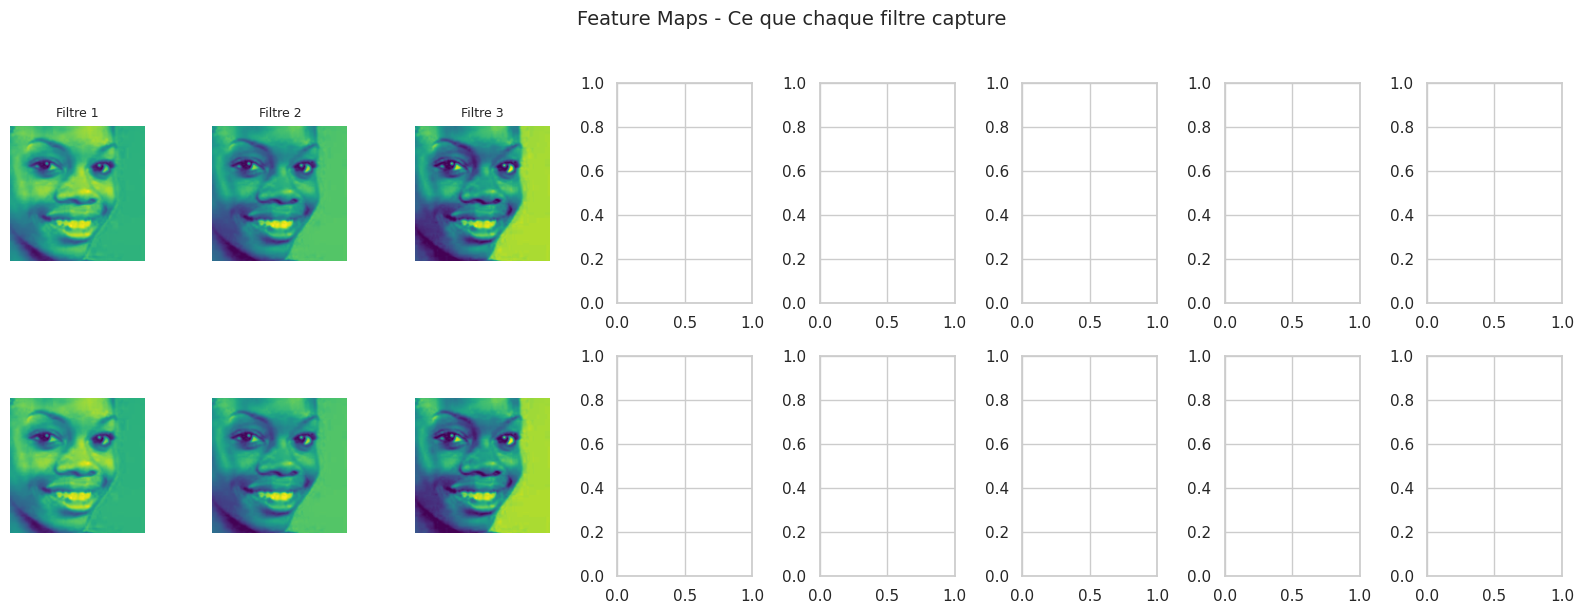

In [17]:
# Visualiser les activations à différents niveaux
# On va prendre 3 couches: début, milieu, fin

layer_indices = [2, len(selected_layers) // 2, len(selected_layers) - 2]
layers_to_viz = [
    selected_layers[i][0] for i in layer_indices if i < len(selected_layers)
]

print(f"Couches à visualiser: {layers_to_viz}")

if layers_to_viz:
    visualize_feature_maps(backbone, sample_batch, layers_to_viz)

## 2.2 Visualisation des Poids des Filtres

Les poids des premiers filtres montrent les patterns basiques que le réseau détecte.


Couche: conv
  Shape des poids: (3, 3, 3, 16)
  (hauteur, largeur, canaux_entrée, nombre_filtres)


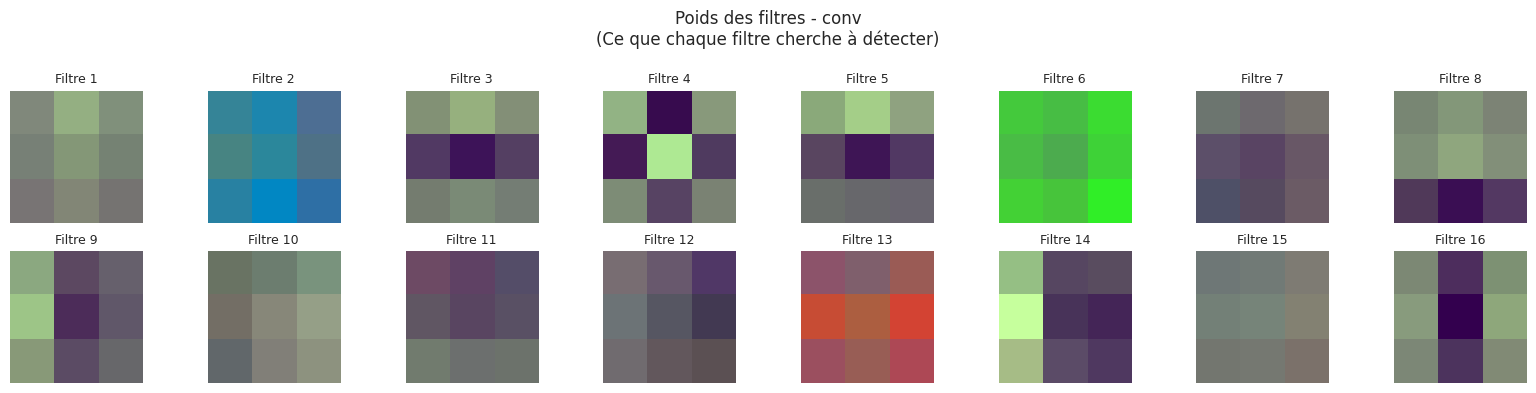

In [18]:
def visualize_filters(model, layer_name, n_filters=16):
    """
    Visualise les poids des filtres d'une couche convolutionnelle.

    Les premiers filtres apprennent généralement:
    - Détecteurs de bords (horizontaux, verticaux, diagonaux)
    - Détecteurs de couleurs
    - Détecteurs de textures basiques
    """
    try:
        layer = model.get_layer(layer_name)
        weights = layer.get_weights()[0]  # Shape: (h, w, in_channels, out_channels)

        print(f"Couche: {layer_name}")
        print(f"  Shape des poids: {weights.shape}")
        print(f"  (hauteur, largeur, canaux_entrée, nombre_filtres)")

        # Normaliser les poids pour visualisation
        weights_min = weights.min()
        weights_max = weights.max()
        weights_norm = (weights - weights_min) / (weights_max - weights_min + 1e-8)

        n_filters = min(n_filters, weights.shape[3])
        n_cols = 8
        n_rows = (n_filters + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

        for i in range(n_filters):
            # Si le filtre a 3 canaux d'entrée, on peut l'afficher en RGB
            if weights.shape[2] == 3:
                filter_img = weights_norm[:, :, :, i]
            else:
                # Sinon, prendre la moyenne des canaux
                filter_img = weights_norm[:, :, :, i].mean(axis=2)

            axes[i].imshow(
                filter_img, cmap="gray" if len(filter_img.shape) == 2 else None
            )
            axes[i].axis("off")
            axes[i].set_title(f"Filtre {i+1}", fontsize=9)

        # Cacher les axes vides
        for i in range(n_filters, len(axes)):
            axes[i].axis("off")

        plt.suptitle(
            f"Poids des filtres - {layer_name}\n(Ce que chaque filtre cherche à détecter)",
            fontsize=12,
        )
        plt.tight_layout()
        plt.savefig(
            ARTIFACTS_DIR / f"filter_weights_{layer_name.replace('/', '_')}.png",
            dpi=150,
        )
        plt.show()

    except Exception as e:
        print(f"Erreur: {e}")


# Trouver la première couche conv avec des poids
for layer in backbone.layers:
    if "conv" in layer.name.lower() and len(layer.get_weights()) > 0:
        visualize_filters(backbone, layer.name)
        break

## 2.3 Grad-CAM : Sur quoi le modèle se focalise ?

**Grad-CAM** (Gradient-weighted Class Activation Mapping) montre les régions de l'image qui influencent le plus la prédiction.

On va voir sur quoi le modèle se focalise pour:

- La prédiction du **Genre**
- La prédiction de l'**Âge**
- La prédiction de l'**Ethnicité**


In [19]:
def make_gradcam_heatmap(
    model, img_array, last_conv_layer_name, pred_index=None, output_name=None
):
    """
    Génère une heatmap Grad-CAM pour visualiser l'attention du modèle.

    Args:
        model: Le modèle Keras
        img_array: Image d'entrée (batch)
        last_conv_layer_name: Nom de la dernière couche conv
        pred_index: Index de la classe à analyser
        output_name: Nom de la sortie (age_output, gender_output, ethnicity_output)
    """
    # Créer un modèle qui retourne les activations de la dernière conv + les prédictions
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Pour un modèle multi-output, on doit spécifier quelle sortie analyser
    if output_name:
        output = model.get_layer(output_name).output
    else:
        output = model.output[0] if isinstance(model.output, list) else model.output

    grad_model = Model(inputs=model.inputs, outputs=[last_conv_layer.output, output])

    # Calculer le gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            if len(predictions.shape) > 1 and predictions.shape[-1] > 1:
                pred_index = tf.argmax(predictions[0])
            else:
                pred_index = 0

        if len(predictions.shape) > 1 and predictions.shape[-1] > 1:
            class_channel = predictions[:, pred_index]
        else:
            class_channel = predictions[:, 0]

    # Gradient des activations
    grads = tape.gradient(class_channel, conv_outputs)

    # Pooling des gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Pondérer les activations par les gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normaliser
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def display_gradcam(img_path, heatmap, alpha=0.4, title=""):
    """Superpose la heatmap Grad-CAM sur l'image originale."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Redimensionner la heatmap
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    # Convertir en colormap
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superposer
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)

    return img, heatmap_resized, superimposed

In [20]:
# Trouver la dernière couche conv du backbone
last_conv_layer = None
for layer in reversed(backbone.layers):
    if "conv" in layer.name.lower() or "expanded" in layer.name.lower():
        try:
            output_shape = layer.output.shape
            if len(output_shape) == 4:  # (batch, h, w, channels)
                last_conv_layer = layer.name
                break
        except:
            continue

print(f"Dernière couche conv: {last_conv_layer}")

Dernière couche conv: conv_1_bn


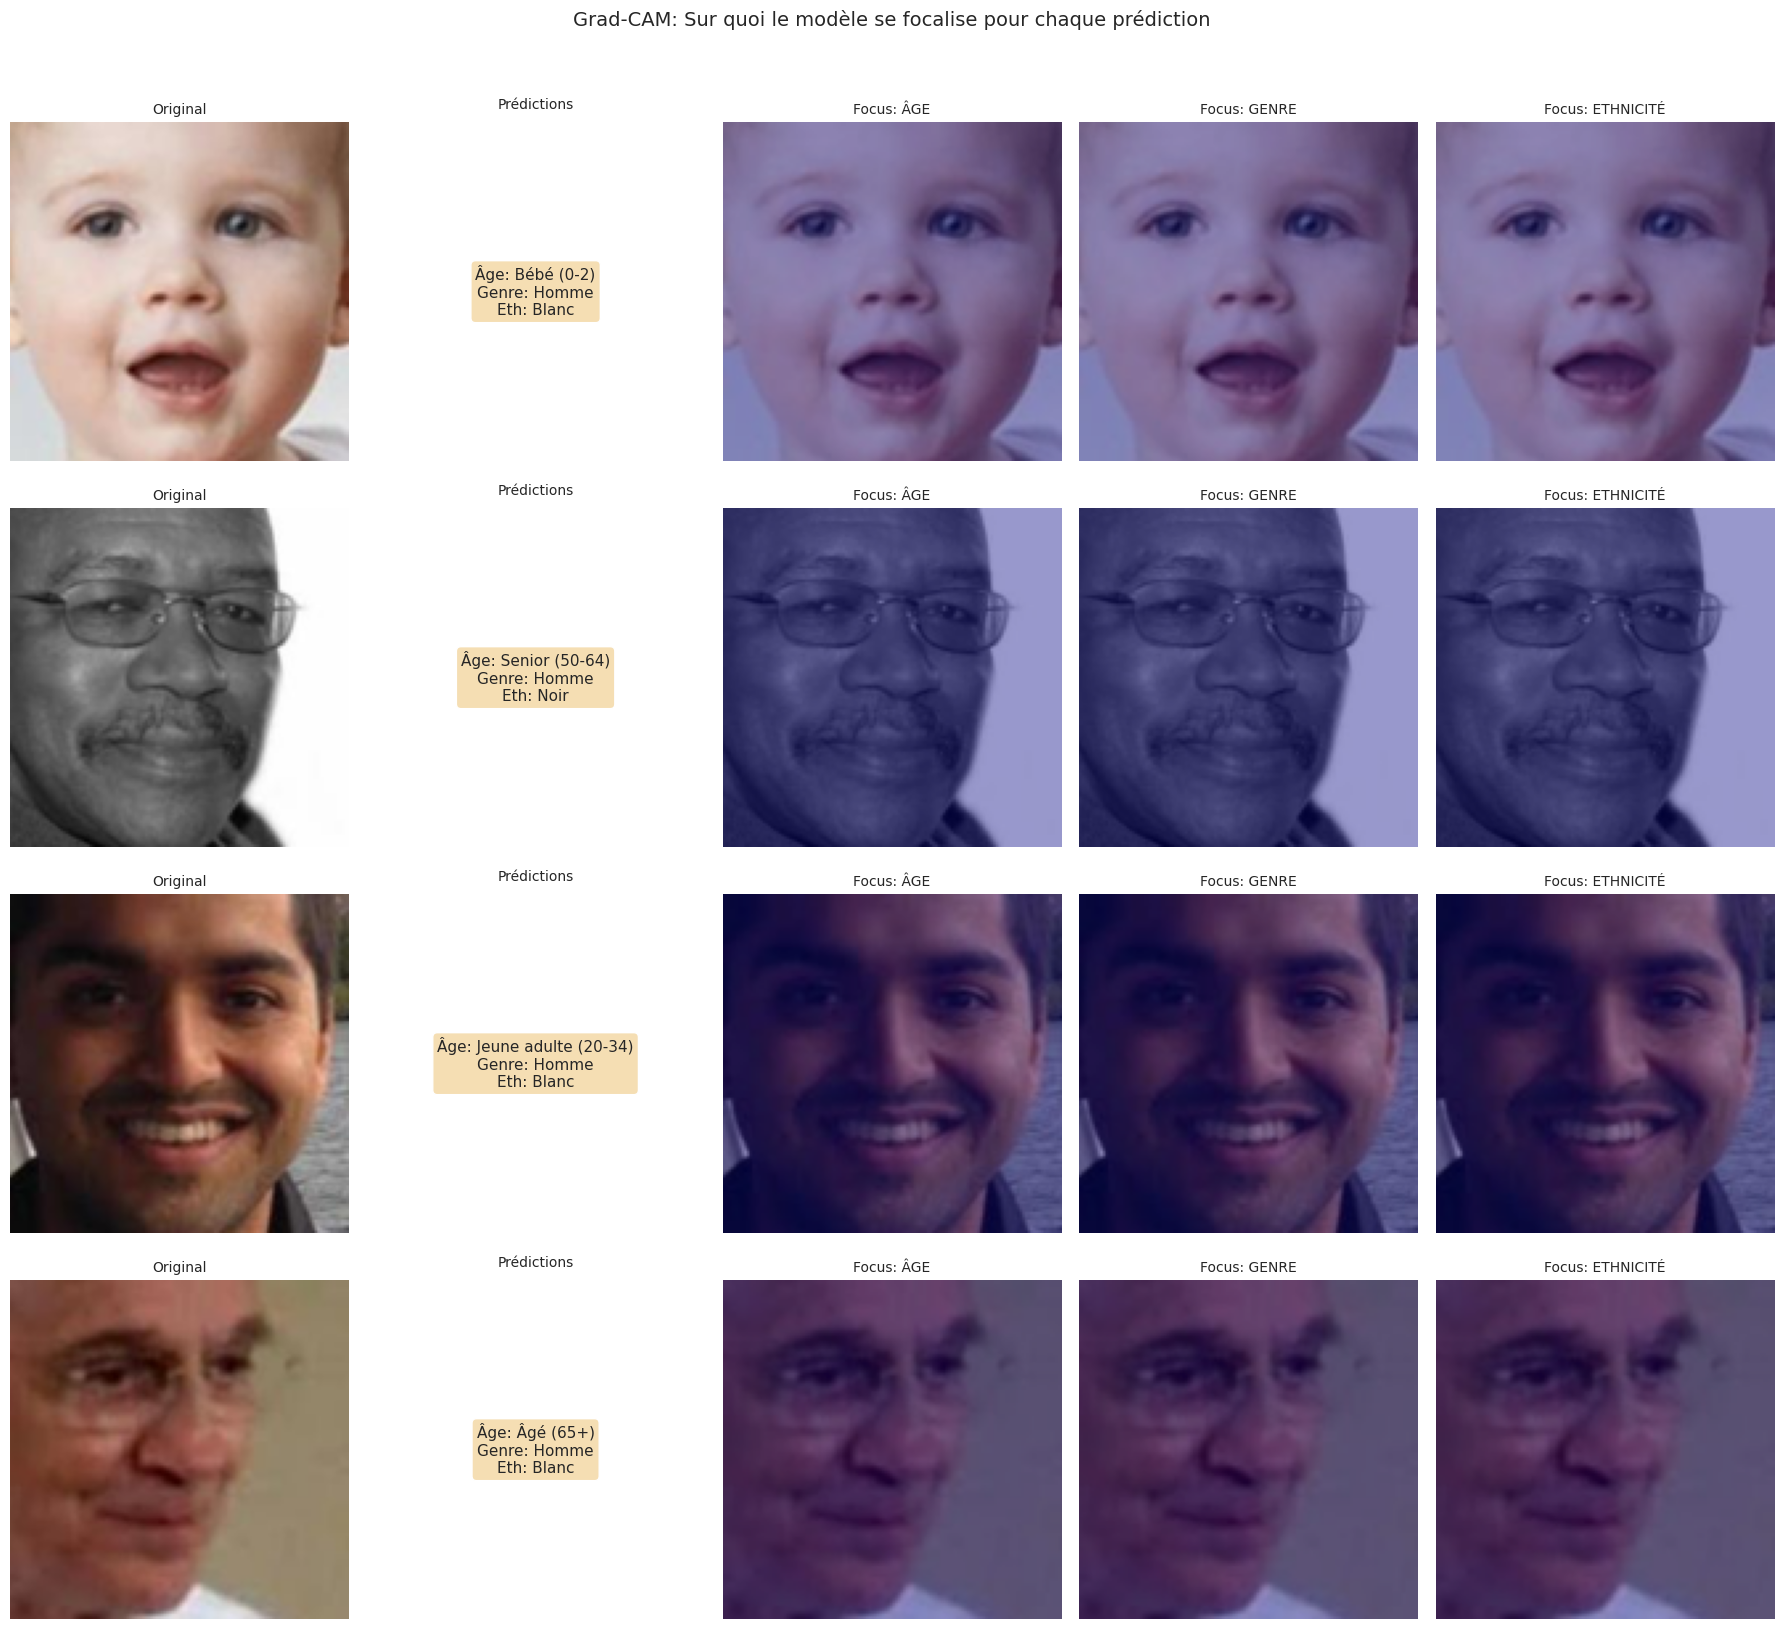


💡 Interprétation des heatmaps:
   - Rouge/Jaune: Zones importantes pour la décision
   - Bleu/Vert: Zones moins importantes

   Observations typiques:
   - ÂGE: Focus sur rides, texture de peau, contour du visage
   - GENRE: Focus sur mâchoire, sourcils, forme générale
   - ETHNICITÉ: Focus sur teint, traits du visage, yeux


In [21]:
# Visualiser Grad-CAM pour plusieurs images et les 3 sorties

# Sélectionner quelques images de test
n_samples = 4
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 5, figsize=(18, 4 * n_samples))

output_names = ["age_output", "gender_output", "ethnicity_output"]
output_titles = ["ÂGE", "GENRE", "ETHNICITÉ"]

for row, idx in enumerate(sample_indices):
    img_path = X_test[idx]

    # Charger et prétraiter l'image
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype(np.float32)
    img_batch = np.expand_dims(img_array, axis=0)

    # Image originale
    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Original", fontsize=10)
    axes[row, 0].axis("off")

    # Prédictions
    preds = model.predict(img_batch, verbose=0)
    pred_age = AGE_LABELS[np.argmax(preds[0])]
    pred_gender = "Femme" if preds[1][0] > 0.5 else "Homme"
    pred_eth = ["Blanc", "Noir", "Asiatique", "Indien", "Autre"][np.argmax(preds[2])]

    # Afficher les prédictions
    info_text = f"Âge: {pred_age}\nGenre: {pred_gender}\nEth: {pred_eth}"
    axes[row, 1].text(
        0.5,
        0.5,
        info_text,
        ha="center",
        va="center",
        fontsize=11,
        transform=axes[row, 1].transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat"),
    )
    axes[row, 1].set_title("Prédictions", fontsize=10)
    axes[row, 1].axis("off")

    # Grad-CAM pour chaque sortie
    for col, (out_name, out_title) in enumerate(zip(output_names, output_titles)):
        try:
            heatmap = make_gradcam_heatmap(
                model, img_batch, last_conv_layer, output_name=out_name
            )
            _, _, superimposed = display_gradcam(img_path, heatmap)
            axes[row, col + 2].imshow(superimposed)
            axes[row, col + 2].set_title(f"Focus: {out_title}", fontsize=10)
        except Exception as e:
            axes[row, col + 2].text(
                0.5, 0.5, f"Erreur\n{str(e)[:30]}", ha="center", va="center"
            )
            axes[row, col + 2].set_title(f"Focus: {out_title}", fontsize=10)
        axes[row, col + 2].axis("off")

plt.suptitle(
    "Grad-CAM: Sur quoi le modèle se focalise pour chaque prédiction",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "gradcam_all_outputs.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 Interprétation des heatmaps:")
print("   - Rouge/Jaune: Zones importantes pour la décision")
print("   - Bleu/Vert: Zones moins importantes")
print("\n   Observations typiques:")
print("   - ÂGE: Focus sur rides, texture de peau, contour du visage")
print("   - GENRE: Focus sur mâchoire, sourcils, forme générale")
print("   - ETHNICITÉ: Focus sur teint, traits du visage, yeux")

## 2.4 Résumé des Observations


In [22]:
print("\n" + "=" * 70)
print("      RÉSUMÉ: CE QUE LE MODÈLE CAPTURE À CHAQUE NIVEAU")
print("=" * 70)

print(
    """
┌─────────────────────────────────────────────────────────────────────┐
│                    HIÉRARCHIE DES FEATURES                          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  COUCHE 1 (Premiers filtres):                                       │
│  ├── Détecteurs de bords (horizontaux, verticaux, diagonaux)        │
│  ├── Détecteurs de couleurs basiques                                │
│  └── Gradients de luminosité                                        │
│                                                                     │
│  COUCHES 2-3 (Filtres intermédiaires bas):                          │
│  ├── Textures (peau, cheveux)                                       │
│  ├── Patterns répétitifs                                            │
│  └── Combinaisons de bords → formes simples                         │
│                                                                     │
│  COUCHES INTERMÉDIAIRES:                                            │
│  ├── Parties du visage (yeux, nez, bouche)                          │
│  ├── Contours du visage                                             │
│  └── Caractéristiques locales discriminantes                        │
│                                                                     │
│  COUCHES PROFONDES:                                                 │
│  ├── Représentations abstraites du visage                           │
│  ├── Identité / Expression                                          │
│  └── Features globales pour la classification                       │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                    FOCUS PAR TÂCHE (Grad-CAM)                       │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  🎂 ÂGE:                                                            │
│  ├── Rides (front, yeux, bouche)                                    │
│  ├── Texture de la peau                                             │
│  ├── Affaissement des traits                                        │
│  └── Zone autour des yeux (pattes d'oie)                            │
│                                                                     │
│  👫 GENRE:                                                          │
│  ├── Forme de la mâchoire                                           │
│  ├── Sourcils (épaisseur, forme)                                    │
│  ├── Pommettes                                                      │
│  └── Structure globale du visage                                    │
│                                                                     │
│  🌍 ETHNICITÉ:                                                      │
│  ├── Couleur/teint de la peau                                       │
│  ├── Forme des yeux                                                 │
│  ├── Forme du nez                                                   │
│  └── Structure osseuse                                              │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
"""
)

print("\n📊 MÉTRIQUES FINALES:")
print(
    f"   • Âge (Classification {NUM_AGE_CLASSES} classes): {accuracy_score(y_age_test, y_pred_age)*100:.1f}%"
)
print(f"   • Genre: {accuracy_score(y_gender_test, y_pred_gender)*100:.1f}%")
print(f"   • Ethnicité: {accuracy_score(y_eth_test, y_pred_ethnicity)*100:.1f}%")


      RÉSUMÉ: CE QUE LE MODÈLE CAPTURE À CHAQUE NIVEAU

┌─────────────────────────────────────────────────────────────────────┐
│                    HIÉRARCHIE DES FEATURES                          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  COUCHE 1 (Premiers filtres):                                       │
│  ├── Détecteurs de bords (horizontaux, verticaux, diagonaux)        │
│  ├── Détecteurs de couleurs basiques                                │
│  └── Gradients de luminosité                                        │
│                                                                     │
│  COUCHES 2-3 (Filtres intermédiaires bas):                          │
│  ├── Textures (peau, cheveux)                                       │
│  ├── Patterns répétitifs                                            │
│  └── Combinaisons de bords → formes simples                         │
│      

## 3. Sauvegarde


In [23]:
import json

results = {
    "experiment": "Age Classification with Intervals + CNN Filter Visualization",
    "age_intervals": {
        "bins": AGE_BINS,
        "labels": AGE_LABELS,
        "num_classes": NUM_AGE_CLASSES,
    },
    "metrics": {
        "age_accuracy": float(accuracy_score(y_age_test, y_pred_age)),
        "age_f1_macro": float(f1_score(y_age_test, y_pred_age, average="macro")),
        "gender_accuracy": float(accuracy_score(y_gender_test, y_pred_gender)),
        "ethnicity_accuracy": float(accuracy_score(y_eth_test, y_pred_ethnicity)),
    },
    "cnn_insights": {
        "layer1": "Edge detection, basic colors, gradients",
        "layer2_3": "Textures, patterns, simple shapes",
        "middle_layers": "Face parts (eyes, nose, mouth), contours",
        "deep_layers": "Abstract face representations, identity features",
    },
    "gradcam_focus": {
        "age": "Wrinkles, skin texture, eye area, face contours",
        "gender": "Jaw shape, eyebrows, cheekbones, overall structure",
        "ethnicity": "Skin tone, eye shape, nose shape, bone structure",
    },
}

with open(ARTIFACTS_DIR / "age_intervals_and_filters_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Résultats sauvegardés!")
print("\nFichiers générés:")
print("  - age_intervals_distribution.png")
print("  - age_classification_confusion_matrix.png")
print("  - feature_maps_visualization.png")
print("  - filter_weights_*.png")
print("  - gradcam_all_outputs.png")
print("  - age_intervals_and_filters_results.json")

Résultats sauvegardés!

Fichiers générés:
  - age_intervals_distribution.png
  - age_classification_confusion_matrix.png
  - feature_maps_visualization.png
  - filter_weights_*.png
  - gradcam_all_outputs.png
  - age_intervals_and_filters_results.json


---
# PARTIE 3 : Visualisation à partir du Modèle Sauvegardé
---

Cette section permet de charger le modèle entraîné et de faire les visualisations (Feature Maps, Filtres, Grad-CAM) sans avoir à ré-entraîner.


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# CELLULE AUTONOME - Exécuter uniquement cette section pour visualisation
# ════════════════════════════════════════════════════════════════════════════

import os
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from PIL import Image
from pathlib import Path

# Configuration
IMG_SIZE = 128
ARTIFACTS_DIR = Path("artifacts")
DATA_DIR = Path("data/UTKFace")

# Labels pour l'âge
AGE_LABELS = [
    "Bébé (0-2)",
    "Enfant (3-11)",
    "Ado (12-19)",
    "Jeune adulte (20-34)",
    "Adulte (35-49)",
    "Senior (50-64)",
    "Âgé (65+)",
]

# ════════════════════════════════════════════════════════════════════════════
# 1. CHARGER LE MODÈLE SAUVEGARDÉ
# ════════════════════════════════════════════════════════════════════════════
print("Chargement du modèle...")
model = keras.models.load_model(ARTIFACTS_DIR / "age_classification_model.keras")
print(f"✓ Modèle chargé: {model.name}")
print(f"  Inputs: {model.input_shape}")
print(f"  Outputs: {[o.name for o in model.outputs]}")

# ════════════════════════════════════════════════════════════════════════════
# 2. EXTRAIRE LE BACKBONE (MobileNetV3)
# ════════════════════════════════════════════════════════════════════════════
backbone = None
for layer in model.layers:
    if hasattr(layer, "layers"):  # C'est un sous-modèle imbriqué
        backbone = layer
        print(f"✓ Backbone trouvé: {backbone.name} ({len(backbone.layers)} couches)")
        break

if backbone is None:
    print("⚠ Backbone non trouvé directement, utilisation du modèle complet")
    backbone = model

# ════════════════════════════════════════════════════════════════════════════
# 3. TROUVER LA DERNIÈRE COUCHE CONV
# ════════════════════════════════════════════════════════════════════════════
last_conv_layer_name = None
for layer in reversed(backbone.layers):
    if "conv" in layer.name.lower():
        try:
            shape = layer.output.shape
            if len(shape) == 4:  # (batch, h, w, channels)
                last_conv_layer_name = layer.name
                print(f"✓ Dernière couche conv: {last_conv_layer_name}")
                break
        except:
            continue

# ════════════════════════════════════════════════════════════════════════════
# 4. CHARGER DES IMAGES DE TEST
# ════════════════════════════════════════════════════════════════════════════
image_paths = list(DATA_DIR.glob("*.jpg"))[:500]
test_images = list(
    np.random.choice(image_paths, min(10, len(image_paths)), replace=False)
)
print(f"✓ {len(test_images)} images de test disponibles")

Chargement du modèle...
✓ Modèle chargé: functional_1
  Inputs: (None, 128, 128, 3)
  Outputs: ['keras_tensor_599', 'keras_tensor_601', 'keras_tensor_603']
✓ Backbone trouvé: sequential (5 couches)
✓ 10 images de test disponibles


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# FONCTIONS DE VISUALISATION (redéfinies pour cette section autonome)
# ════════════════════════════════════════════════════════════════════════════


def visualize_feature_maps_standalone(backbone_model, img_batch, n_layers=3):
    """Visualise les feature maps à différentes profondeurs du backbone."""

    # Trouver les couches avec des feature maps 2D
    selected_layers = []
    for layer in backbone_model.layers:
        try:
            shape = layer.output.shape
            if len(shape) == 4 and shape[1] and shape[2]:  # (batch, h, w, c)
                selected_layers.append(layer.name)
        except:
            continue

    if not selected_layers:
        print("Aucune couche avec feature maps trouvée")
        return

    # Sélectionner des couches à différentes profondeurs
    indices = [0, len(selected_layers) // 2, len(selected_layers) - 1]
    layers_to_viz = [selected_layers[i] for i in indices if i < len(selected_layers)]

    print(f"Visualisation des couches: {layers_to_viz}")

    # Créer le modèle d'activation
    outputs = [backbone_model.get_layer(name).output for name in layers_to_viz]
    activation_model = Model(inputs=backbone_model.input, outputs=outputs)
    activations = activation_model.predict(img_batch, verbose=0)

    # Afficher
    fig, axes = plt.subplots(len(activations), 8, figsize=(16, 3 * len(activations)))
    if len(activations) == 1:
        axes = [axes]

    for layer_idx, (layer_name, activation) in enumerate(
        zip(layers_to_viz, activations)
    ):
        n_filters = min(8, activation.shape[-1])
        for filter_idx in range(n_filters):
            ax = axes[layer_idx][filter_idx]
            ax.imshow(activation[0, :, :, filter_idx], cmap="viridis")
            ax.axis("off")
            if filter_idx == 0:
                ax.set_ylabel(layer_name[:20], fontsize=8, rotation=0, ha="right")
        if layer_idx == 0:
            for i in range(n_filters):
                axes[0][i].set_title(f"Filtre {i+1}", fontsize=9)

    plt.suptitle(
        "Feature Maps - Activations à différentes profondeurs", fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.savefig(
        ARTIFACTS_DIR / "feature_maps_standalone.png", dpi=150, bbox_inches="tight"
    )
    plt.show()


def visualize_filters_standalone(backbone_model, n_filters=16):
    """Visualise les poids de la première couche conv."""

    # Trouver la première couche conv avec des poids
    for layer in backbone_model.layers:
        if "conv" in layer.name.lower():
            weights = layer.get_weights()
            if weights:
                weights = weights[0]
                print(f"Couche: {layer.name}")
                print(f"  Shape des poids: {weights.shape}")

                # Normaliser
                w_min, w_max = weights.min(), weights.max()
                weights_norm = (weights - w_min) / (w_max - w_min + 1e-8)

                n_filters = min(n_filters, weights.shape[3])
                n_cols = 8
                n_rows = (n_filters + n_cols - 1) // n_cols

                fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
                axes = axes.flatten() if n_rows > 1 else [axes]

                for i in range(n_filters):
                    if weights.shape[2] == 3:
                        filter_img = weights_norm[:, :, :, i]
                    else:
                        filter_img = weights_norm[:, :, :, i].mean(axis=2)

                    axes[i].imshow(
                        filter_img, cmap="gray" if len(filter_img.shape) == 2 else None
                    )
                    axes[i].axis("off")
                    axes[i].set_title(f"Filtre {i+1}", fontsize=9)

                for i in range(n_filters, len(axes)):
                    axes[i].axis("off")

                plt.suptitle(f"Poids des filtres - {layer.name}", fontsize=12)
                plt.tight_layout()
                plt.savefig(ARTIFACTS_DIR / "filter_weights_standalone.png", dpi=150)
                plt.show()
                return

    print("Aucune couche conv avec poids trouvée")


def make_gradcam_heatmap_standalone(
    model, img_array, last_conv_layer_name, output_name=None
):
    """Génère une heatmap Grad-CAM."""

    # Récupérer la couche conv (peut être dans un sous-modèle)
    last_conv_layer = None
    for layer in model.layers:
        if layer.name == last_conv_layer_name:
            last_conv_layer = layer
            break
        if hasattr(layer, "layers"):  # Sous-modèle
            for sublayer in layer.layers:
                if sublayer.name == last_conv_layer_name:
                    last_conv_layer = sublayer
                    break

    if last_conv_layer is None:
        raise ValueError(f"Couche {last_conv_layer_name} non trouvée")

    # Sortie à analyser
    if output_name:
        output = model.get_layer(output_name).output
    else:
        output = model.output[0] if isinstance(model.output, list) else model.output

    # Modèle gradient
    grad_model = Model(inputs=model.inputs, outputs=[last_conv_layer.output, output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if len(predictions.shape) > 1 and predictions.shape[-1] > 1:
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
        else:
            class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def display_gradcam_standalone(img_path, heatmap, alpha=0.4):
    """Superpose la heatmap sur l'image."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, heatmap_resized, superimposed


print("✓ Fonctions de visualisation définies")

✓ Fonctions de visualisation définies


⚠ Utilisation du modèle complet comme backbone
✓ Dernière couche conv: conv_1_bn
         VISUALISATIONS CNN - MODÈLE SAUVEGARDÉ


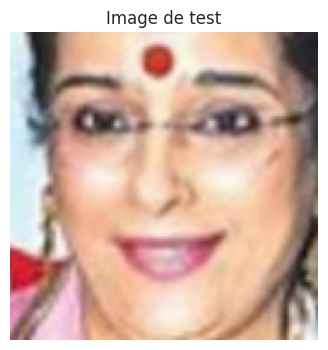


📊 1. FEATURE MAPS (Activations)
----------------------------------------
Visualisation des couches: ['input_layer', 'expanded_conv_5_project_bn', 'activation_17']


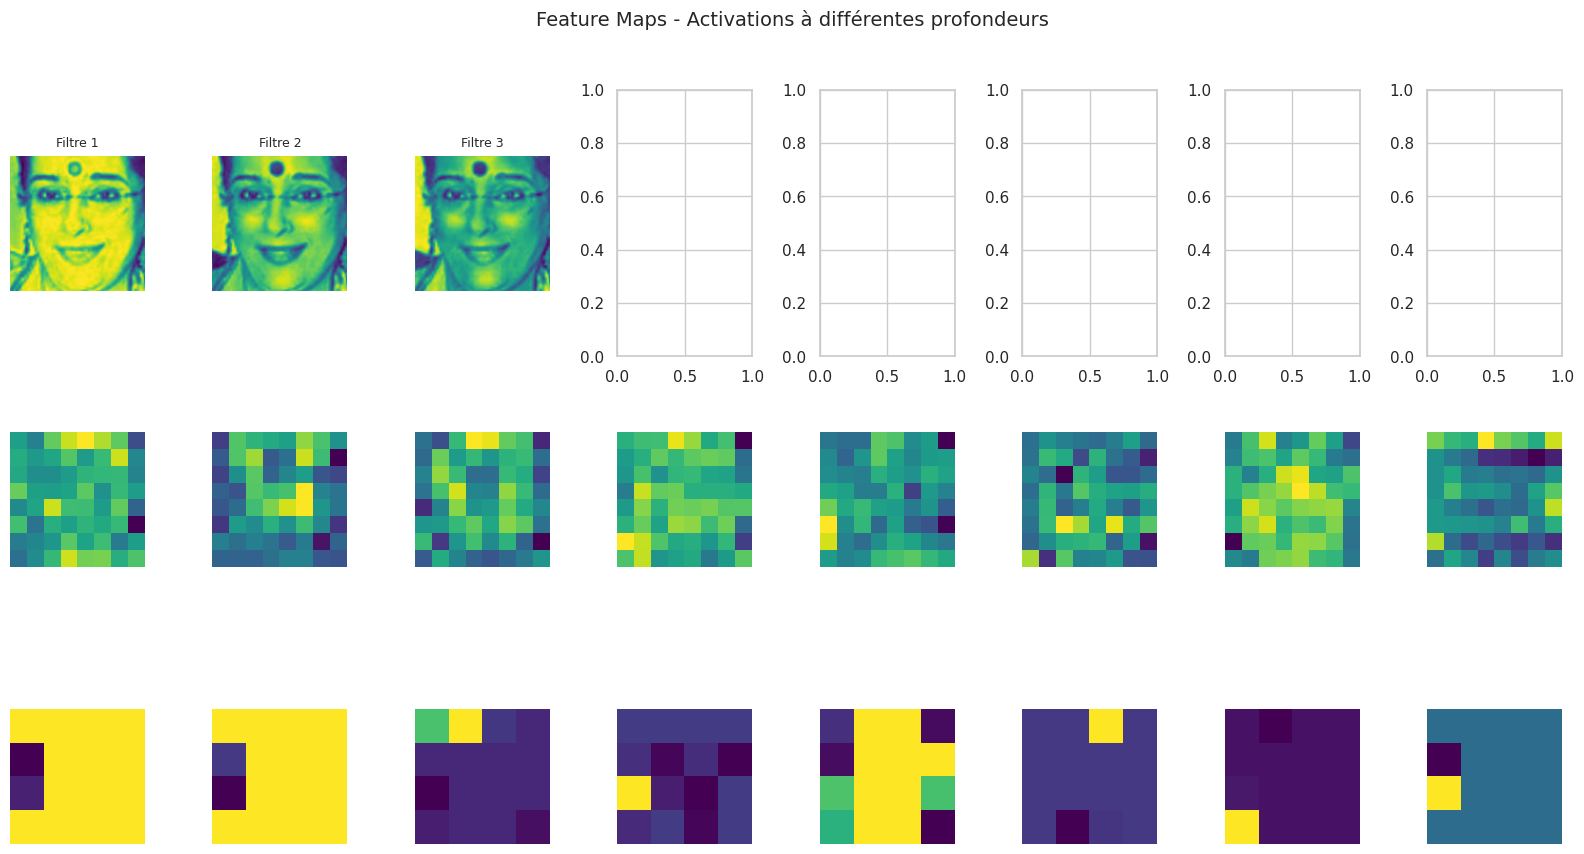


🔍 2. POIDS DES FILTRES
----------------------------------------
Couche: conv
  Shape des poids: (3, 3, 3, 16)


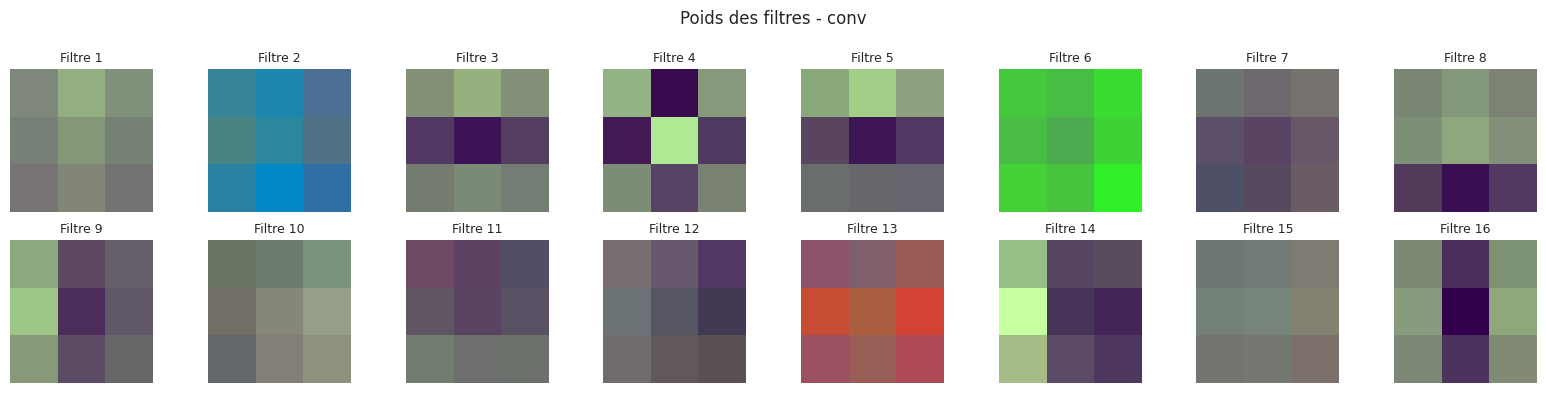


🎯 3. GRAD-CAM
----------------------------------------


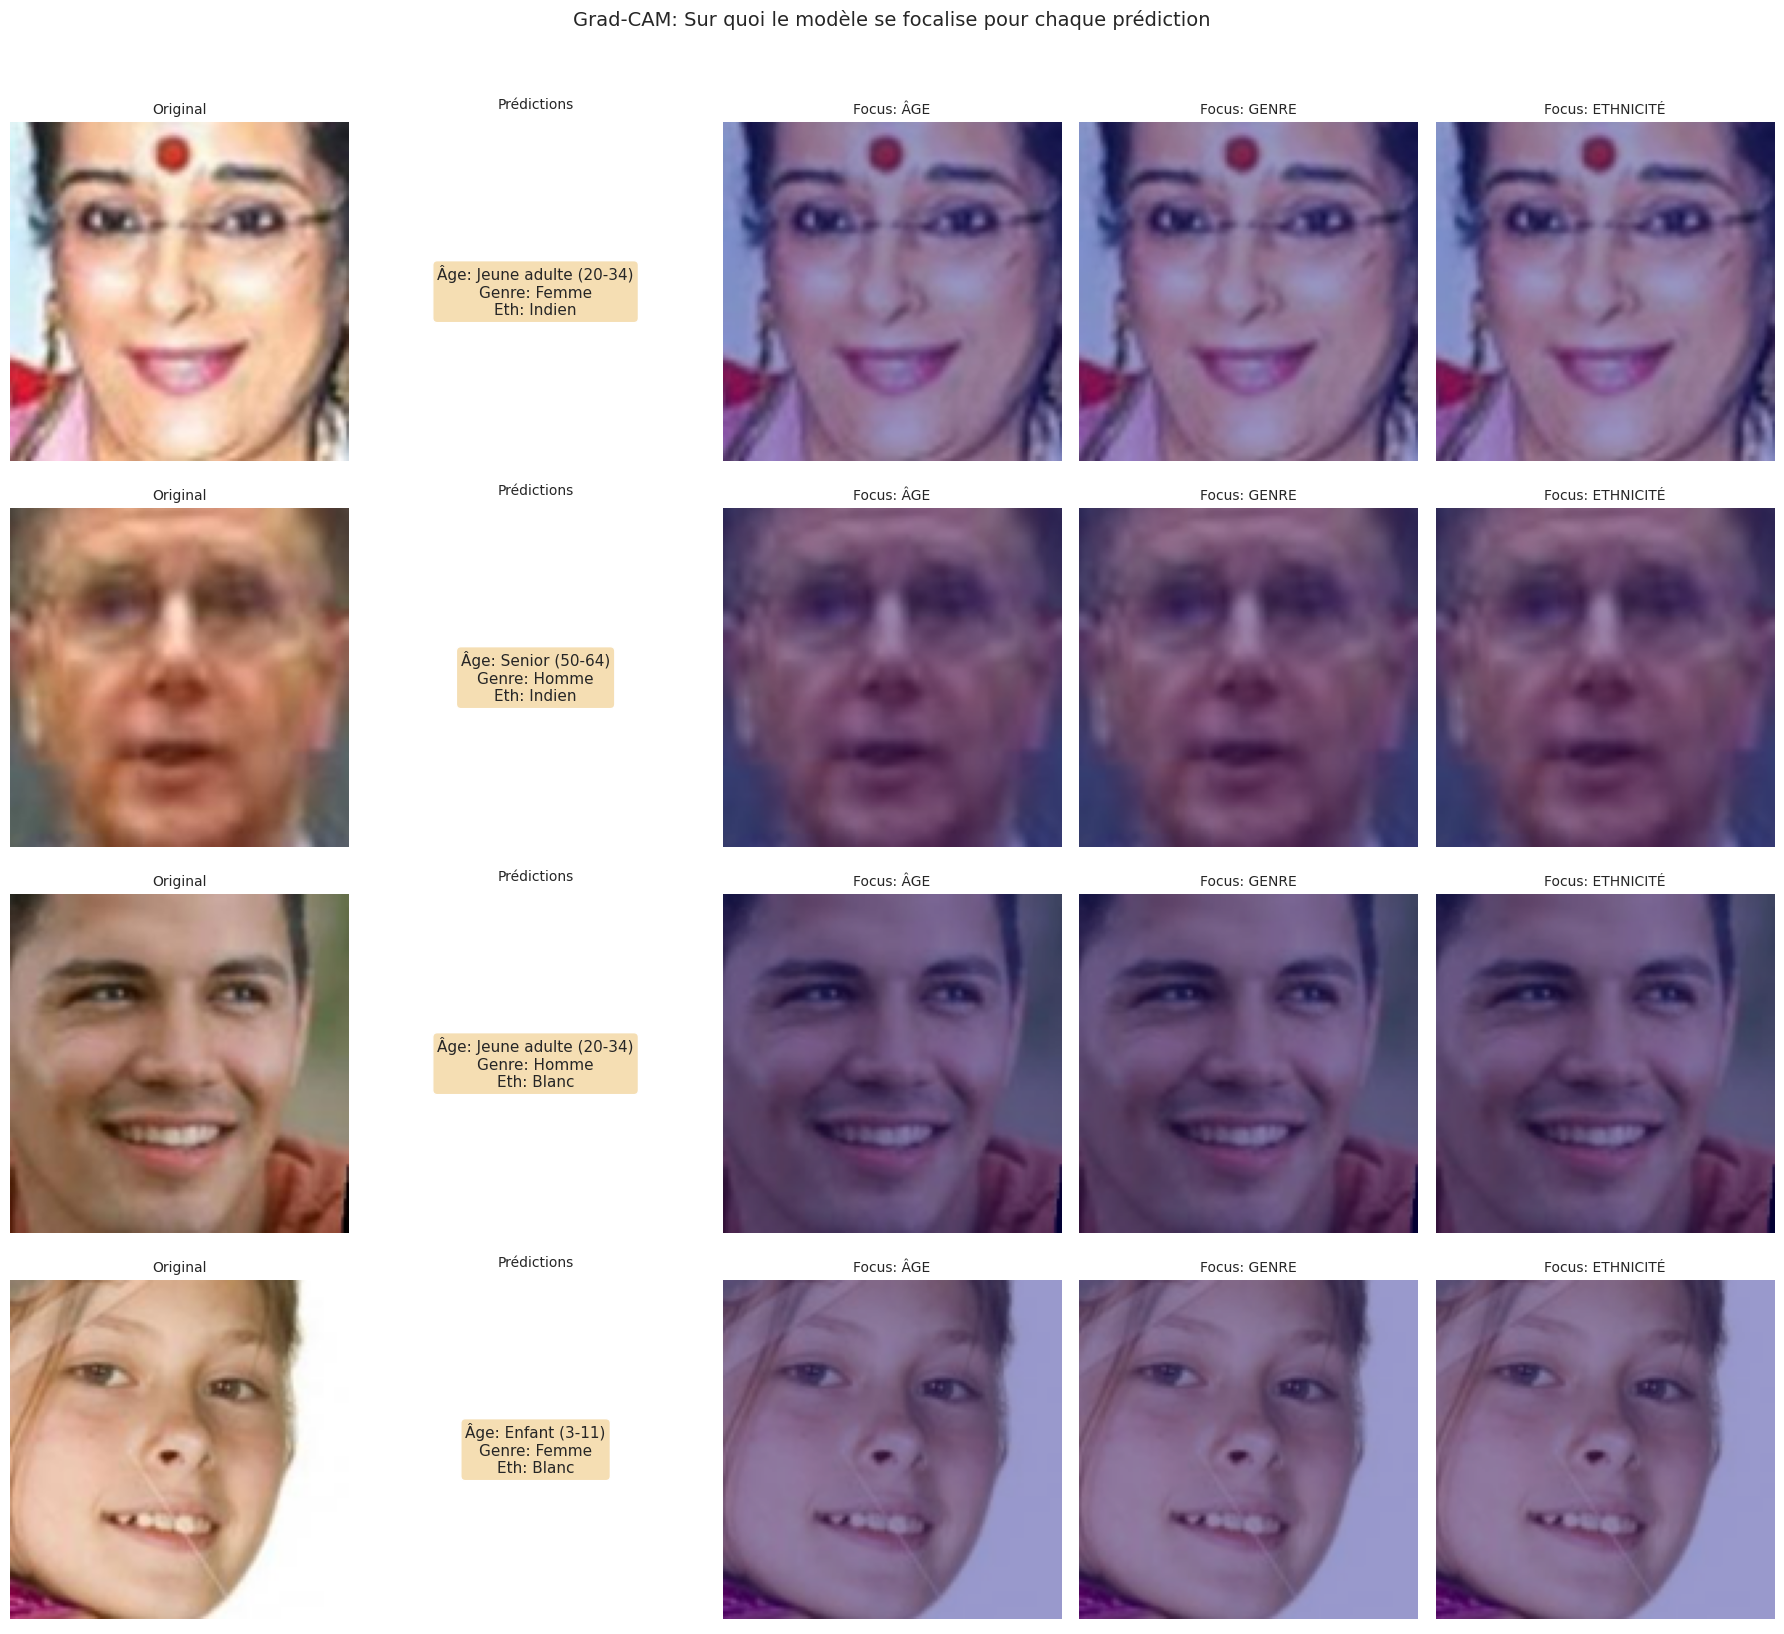


✅ Visualisations terminées!

💡 Interprétation:
   - Rouge/Jaune: Zones importantes pour la décision
   - Bleu/Vert: Zones moins importantes


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# EXÉCUTER LES VISUALISATIONS
# ════════════════════════════════════════════════════════════════════════════

backbone_viz = None
for layer in model.layers:
    if hasattr(layer, "layers") and len(layer.layers) > 10:
        has_conv = any("conv" in l.name.lower() for l in layer.layers)
        if has_conv:
            backbone_viz = layer
            break

if backbone_viz is None:
    backbone_viz = model
    print("⚠ Utilisation du modèle complet comme backbone")
else:
    print(
        f"✓ Backbone pour visualisation: {backbone_viz.name} ({len(backbone_viz.layers)} couches)"
    )

last_conv_layer_name = None
for layer in reversed(backbone_viz.layers):
    if "conv" in layer.name.lower():
        try:
            shape = layer.output.shape
            if len(shape) == 4:
                last_conv_layer_name = layer.name
                break
        except:
            continue

print(f"✓ Dernière couche conv: {last_conv_layer_name}")

sample_path = test_images[0]
sample_img = Image.open(sample_path).resize((IMG_SIZE, IMG_SIZE))
sample_array = np.array(sample_img).astype(np.float32)
sample_batch = np.expand_dims(sample_array, axis=0)

print("=" * 60)
print("         VISUALISATIONS CNN - MODÈLE SAUVEGARDÉ")
print("=" * 60)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title("Image de test")
plt.axis("off")
plt.show()

print("\n📊 1. FEATURE MAPS (Activations)")
print("-" * 40)
visualize_feature_maps_standalone(backbone_viz, sample_batch)

print("\n🔍 2. POIDS DES FILTRES")
print("-" * 40)
visualize_filters_standalone(backbone_viz)

print("\n🎯 3. GRAD-CAM")
print("-" * 40)

n_samples = 4
fig, axes = plt.subplots(n_samples, 5, figsize=(18, 4 * n_samples))

output_names = ["age_output", "gender_output", "ethnicity_output"]
output_titles = ["ÂGE", "GENRE", "ETHNICITÉ"]

for row in range(min(n_samples, len(test_images))):
    img_path = test_images[row]
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype(np.float32)
    img_batch = np.expand_dims(img_array, axis=0)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Original", fontsize=10)
    axes[row, 0].axis("off")

    preds = model.predict(img_batch, verbose=0)
    pred_age = AGE_LABELS[np.argmax(preds[0])]
    pred_gender = "Femme" if preds[1][0] > 0.5 else "Homme"
    pred_eth = ["Blanc", "Noir", "Asiatique", "Indien", "Autre"][np.argmax(preds[2])]

    info_text = f"Âge: {pred_age}\nGenre: {pred_gender}\nEth: {pred_eth}"
    axes[row, 1].text(
        0.5,
        0.5,
        info_text,
        ha="center",
        va="center",
        fontsize=11,
        transform=axes[row, 1].transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat"),
    )
    axes[row, 1].set_title("Prédictions", fontsize=10)
    axes[row, 1].axis("off")

    for col, (out_name, out_title) in enumerate(zip(output_names, output_titles)):
        try:
            heatmap = make_gradcam_heatmap_standalone(
                model, img_batch, last_conv_layer_name, output_name=out_name
            )
            _, _, superimposed = display_gradcam_standalone(img_path, heatmap)
            axes[row, col + 2].imshow(superimposed)
            axes[row, col + 2].set_title(f"Focus: {out_title}", fontsize=10)
        except Exception as e:
            axes[row, col + 2].text(
                0.5, 0.5, f"Erreur\n{str(e)[:30]}", ha="center", va="center"
            )
            axes[row, col + 2].set_title(f"Focus: {out_title}", fontsize=10)
        axes[row, col + 2].axis("off")

plt.suptitle(
    "Grad-CAM: Sur quoi le modèle se focalise pour chaque prédiction",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "gradcam_standalone.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Visualisations terminées!")
print("\n💡 Interprétation:")
print("   - Rouge/Jaune: Zones importantes pour la décision")
print("   - Bleu/Vert: Zones moins importantes")